# DATA 3402 Final Project-Summer 2026

## **Assignment Submission Guidelines**


Please follow the guidelines below for submitting your assignment:

1. **Submission Deadline:**
   - All assignments must be submitted **no later than 11:59 PM the final exam day (08/07) Midnight**.
   - Late submissions will not be accepted.

2. **Submission Platform:**
   - Submit your assignment through **Canvas**.

3. **Required Files:**
   - **Jupyter Notebook file (.ipynb):** Submit the Jupyter Notebook file you used to complete the assignment. The file should contain your well-commented code.
   - **PDF Version (.pdf file):** Additionally, submit a PDF version of your Python code. This can be a printout or export of your script, showing all the code with any necessary explanations or output results included.

4. **File Naming Convention:**
   - Please name your files as follows: `Group Name_AssignmentName`
   - Example: `Group 1_Final_Project.ipynb` and `Group 1_Final_Project.pdf`

5. **Technical Issues:**
   - If you encounter any technical issues with Canvas or your submission, please contact the TAs immediately **before the deadline** to avoid penalties.


## Guideline

Your final project presentations will be held on Tuesday, August 4th, from 1:00 PM to 3:00 PM.

Each group will have approximately 20 minutes to present their project and findings.

**Please confirm and sign up for your group by midnight on July 23rd.**

The dataset list file contains the datasets assigned to each group.
You are not limited to these datasets—if you wish to use a different one, please contact Dr. Ce Brian Bian in advance to confirm its suitability.

This notebook serves as a step-by-step guide to help you complete your final project successfully.

This notebook outlines the steps you should follow. Note that you will be only considering classification projects.

## Data Loading and Initial Look

* Load the data.
* Count the number of rows (data points) and features.
* Any missing values?
* Make a table, where each row is a feature or collection of features:
    * Is the feature categorical or numerical
    * What values?
        * e.g. for categorical: "0,1,2"
        * e.g. for numerical specify the range
    * How many missing values
    * Do you see any outliers?
        * Define outlier.
* For classification is there class imbalance?
* What is the target:
    * Classification: how is the target encoded (e.g. 0 and 1)?
    * Regression: what is the range?

In [1]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
import numpy as np
import pandas as pd

df = pd.read_csv('springleaf-marketing-response/train.csv', low_memory=False)

for c in df.select_dtypes('float64').columns:
    df[c] = df[c].astype('float32')

In [2]:
assumed_placeholders = [-1, 96, 97, 98, 99, 996, 997, 998, 999, 9996, 9997, 9998, 9999, 999999996, 999999997, 999999998, 999999999]

rows, cols = df.shape
features = [c for c in df.columns if c not in ('ID', 'target')]
num_cols = df[features].select_dtypes(include=[np.number]).columns.tolist()
str_cols = [c for c in features if c not in num_cols]

print('Row and Feature count:')
print(f'Rows: {rows}')
print(f'Columns: {cols}')
print(f'Features: {len(features)}')

Row and Feature count:
Rows: 145231
Columns: 1934
Features: 1932


In [3]:
missing_count = df[features].isna().sum()
missing_pct = missing_count / rows
num_cells = rows * len(features)

print('Missing values:')
print(f'Features with >= 1 missing: {(missing_count > 0).sum()}')
print(f'Features >50% missing: {(missing_pct > 0.5).sum()}')
print(f'Features 100% missing: {(missing_pct == 1.0).sum()}')

plchldr_count = pd.Series(0, index=num_cols, dtype='int64')
plchldr_rows = []

for plchldr in assumed_placeholders:
    hit = (df[num_cols] == plchldr).sum()
    plchldr_count = plchldr_count + hit
    if hit.sum() > 0:
        plchldr_rows.append({'value': plchldr,
                              'columns': int((hit > 0).sum()),
                              'cells': int(hit.sum())})

plchldr_table = pd.DataFrame(plchldr_rows)
plchldr_table['pct_of_cells'] = (100 * plchldr_table['cells'] / num_cells).round(2)

print('\nAssumed Placeholders:')
print('We will assume certain values are placeholders for missing values.')
print('The true count of missing values is unknown, and is under-reported by pandas')
print('since pandas assumes these values are valid.')
display(plchldr_table)

Missing values:
Features with >= 1 missing: 525
Features >50% missing: 24
Features 100% missing: 3

Assumed Placeholders:
We will assume certain values are placeholders for missing values.
The true count of missing values is unknown, and is under-reported by pandas
since pandas assumes these values are valid.


,value,columns,cells,pct_of_cells
0,-1,117,4962052,1.77
1,96,473,555099,0.20
2,97,659,2535240,0.90
3,98,787,14530873,5.18
4,99,904,430255,0.15
5,996,253,521899,0.19
6,997,352,1920361,0.68
7,998,399,8581074,3.06
8,999,456,143701,0.05
9,9996,186,3872395,1.38


In [4]:
def group_size(n):
    if n <= 1:
        return 'constant (useless)'
    if n <= 10:
        return 'few values (2-10)'
    if n <= 20:
        return 'relatively diverse values (11-20)'
    return 'many values (21+)'

n_unique = df[features].nunique()
kind = df[features].dtypes.astype(str).apply(lambda d: 'number' if d.startswith(('int', 'float')) else 'text')
group = n_unique.apply(group_size)

print('Feature Table')
display(pd.crosstab(kind, group, rownames=['type'], colnames=['distinct values']))

print(f'Constant features (no information): {(n_unique <= 1).sum()}')
print(f'Features with 20 or fewer values: {(n_unique <= 20).sum()}')
print(f'Features more than half missing: {(missing_pct > 0.5).sum()}')

Feature Table


distinct values,constant (useless),few values (2-10),many values (21+),relatively diverse values (11-20)
type,,,,
number,41,439,1180,221
text,13,15,22,1


Constant features (no information): 54
Features with 20 or fewer values: 730
Features more than half missing: 24


In [5]:
print('Outliers:')
print('Definition: An outlier is a data point that lies an abnormal distance from other values in a dataset, significantly differing from the overall pattern or distribution.')
print('Looking for outliers in this dataset is complicated. The only kind of outlier we\'re reasonably able to investigate are placeholder variables.')
print('Since our data is anonymized and unitless, separating outliers from legtimiate values is difficult. For the sake of practicality, we made the ')
print('decision to only try to identify and correct placeholder values as outliers.')

Outliers:
Definition: An outlier is a data point that lies an abnormal distance from other values in a dataset, significantly differing from the overall pattern or distribution.
Looking for outliers in this dataset is complicated. The only kind of outlier we're reasonably able to investigate are placeholder variables.
Since our data is anonymized and unitless, separating outliers from legtimiate values is difficult. For the sake of practicality, we made the 
decision to only try to identify and correct placeholder values as outliers.


In [6]:
target_counts = df['target'].value_counts().sort_index()

print('Class Imbalance:')
for value, count in target_counts.items():
    print(f'{value}: {count} ({round(100 * count / rows, 2)}%)')
print(f'Imbalance in the target variable is noticeable but not extreme.')

Class Imbalance:
0: 111458 (76.75%)
1: 33773 (23.25%)
Imbalance in the target variable is noticeable but not extreme.


In [7]:
print('The target and its encoding:')
print('For this project, the target is "target".')
print('dtpe: int64')
print('Values: {0, 1}')
print('Missing: 0')

The target and its encoding:
For this project, the target is "target".
dtpe: int64
Values: {0, 1}
Missing: 0


## Data Visualization

* For classification: compare histogram every feature between the classes. Lots of examples of this in class.
* For regression:
    * Define 2 or more class based on value of the regression target.
        * For example: if regression target is between 0 and 1:
            * 0.0-0.25: Class 1
            * 0.25-0.5: Class 2
            * 0.5-0.75: Class 3
            * 0.75-1.0: Class 4
    * Compare histograms of the features between the classes.
        
* Note that for categorical features, often times the information in the histogram could be better presented in a table.    
* Make comments on what features look most promising for ML task.

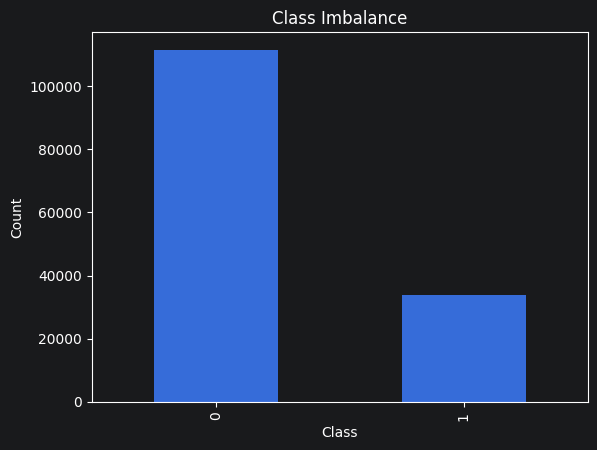

In [8]:
target_counts.plot.bar()
plt.title('Class Imbalance')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

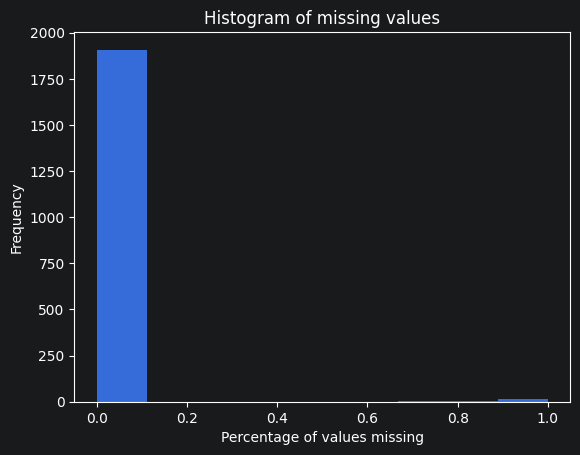

In [9]:
missing_pct.plot.hist(bins=9)
plt.title('Histogram of missing values')
plt.xlabel('Percentage of values missing')
plt.ylabel('Frequency')
plt.show()

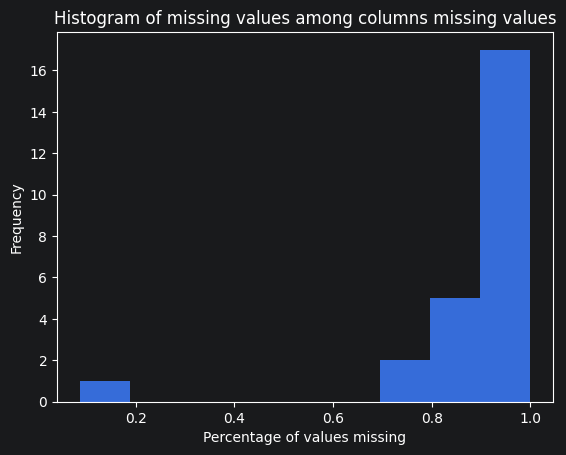

In [10]:
missing_pct[missing_pct > 0.01].plot.hist(bins=9)
plt.title('Histogram of missing values among columns missing values')
plt.ylabel('Frequency')
plt.xlabel('Percentage of values missing')
plt.show()

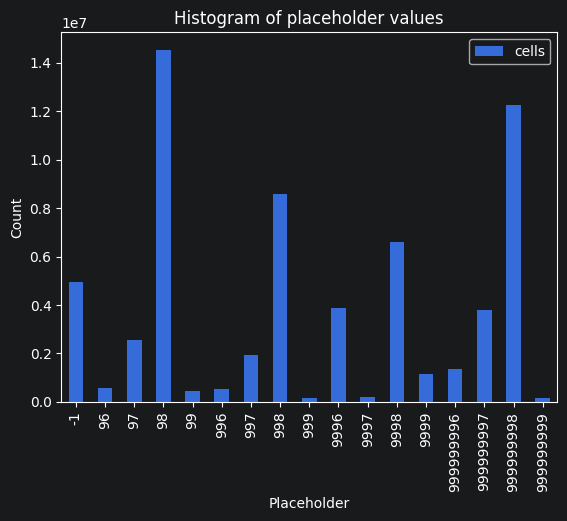

In [11]:
plchldr_table.plot.bar(x='value', y='cells')
plt.xlabel('Placeholder')
plt.ylabel('Count')
plt.title('Histogram of placeholder values')
plt.show()

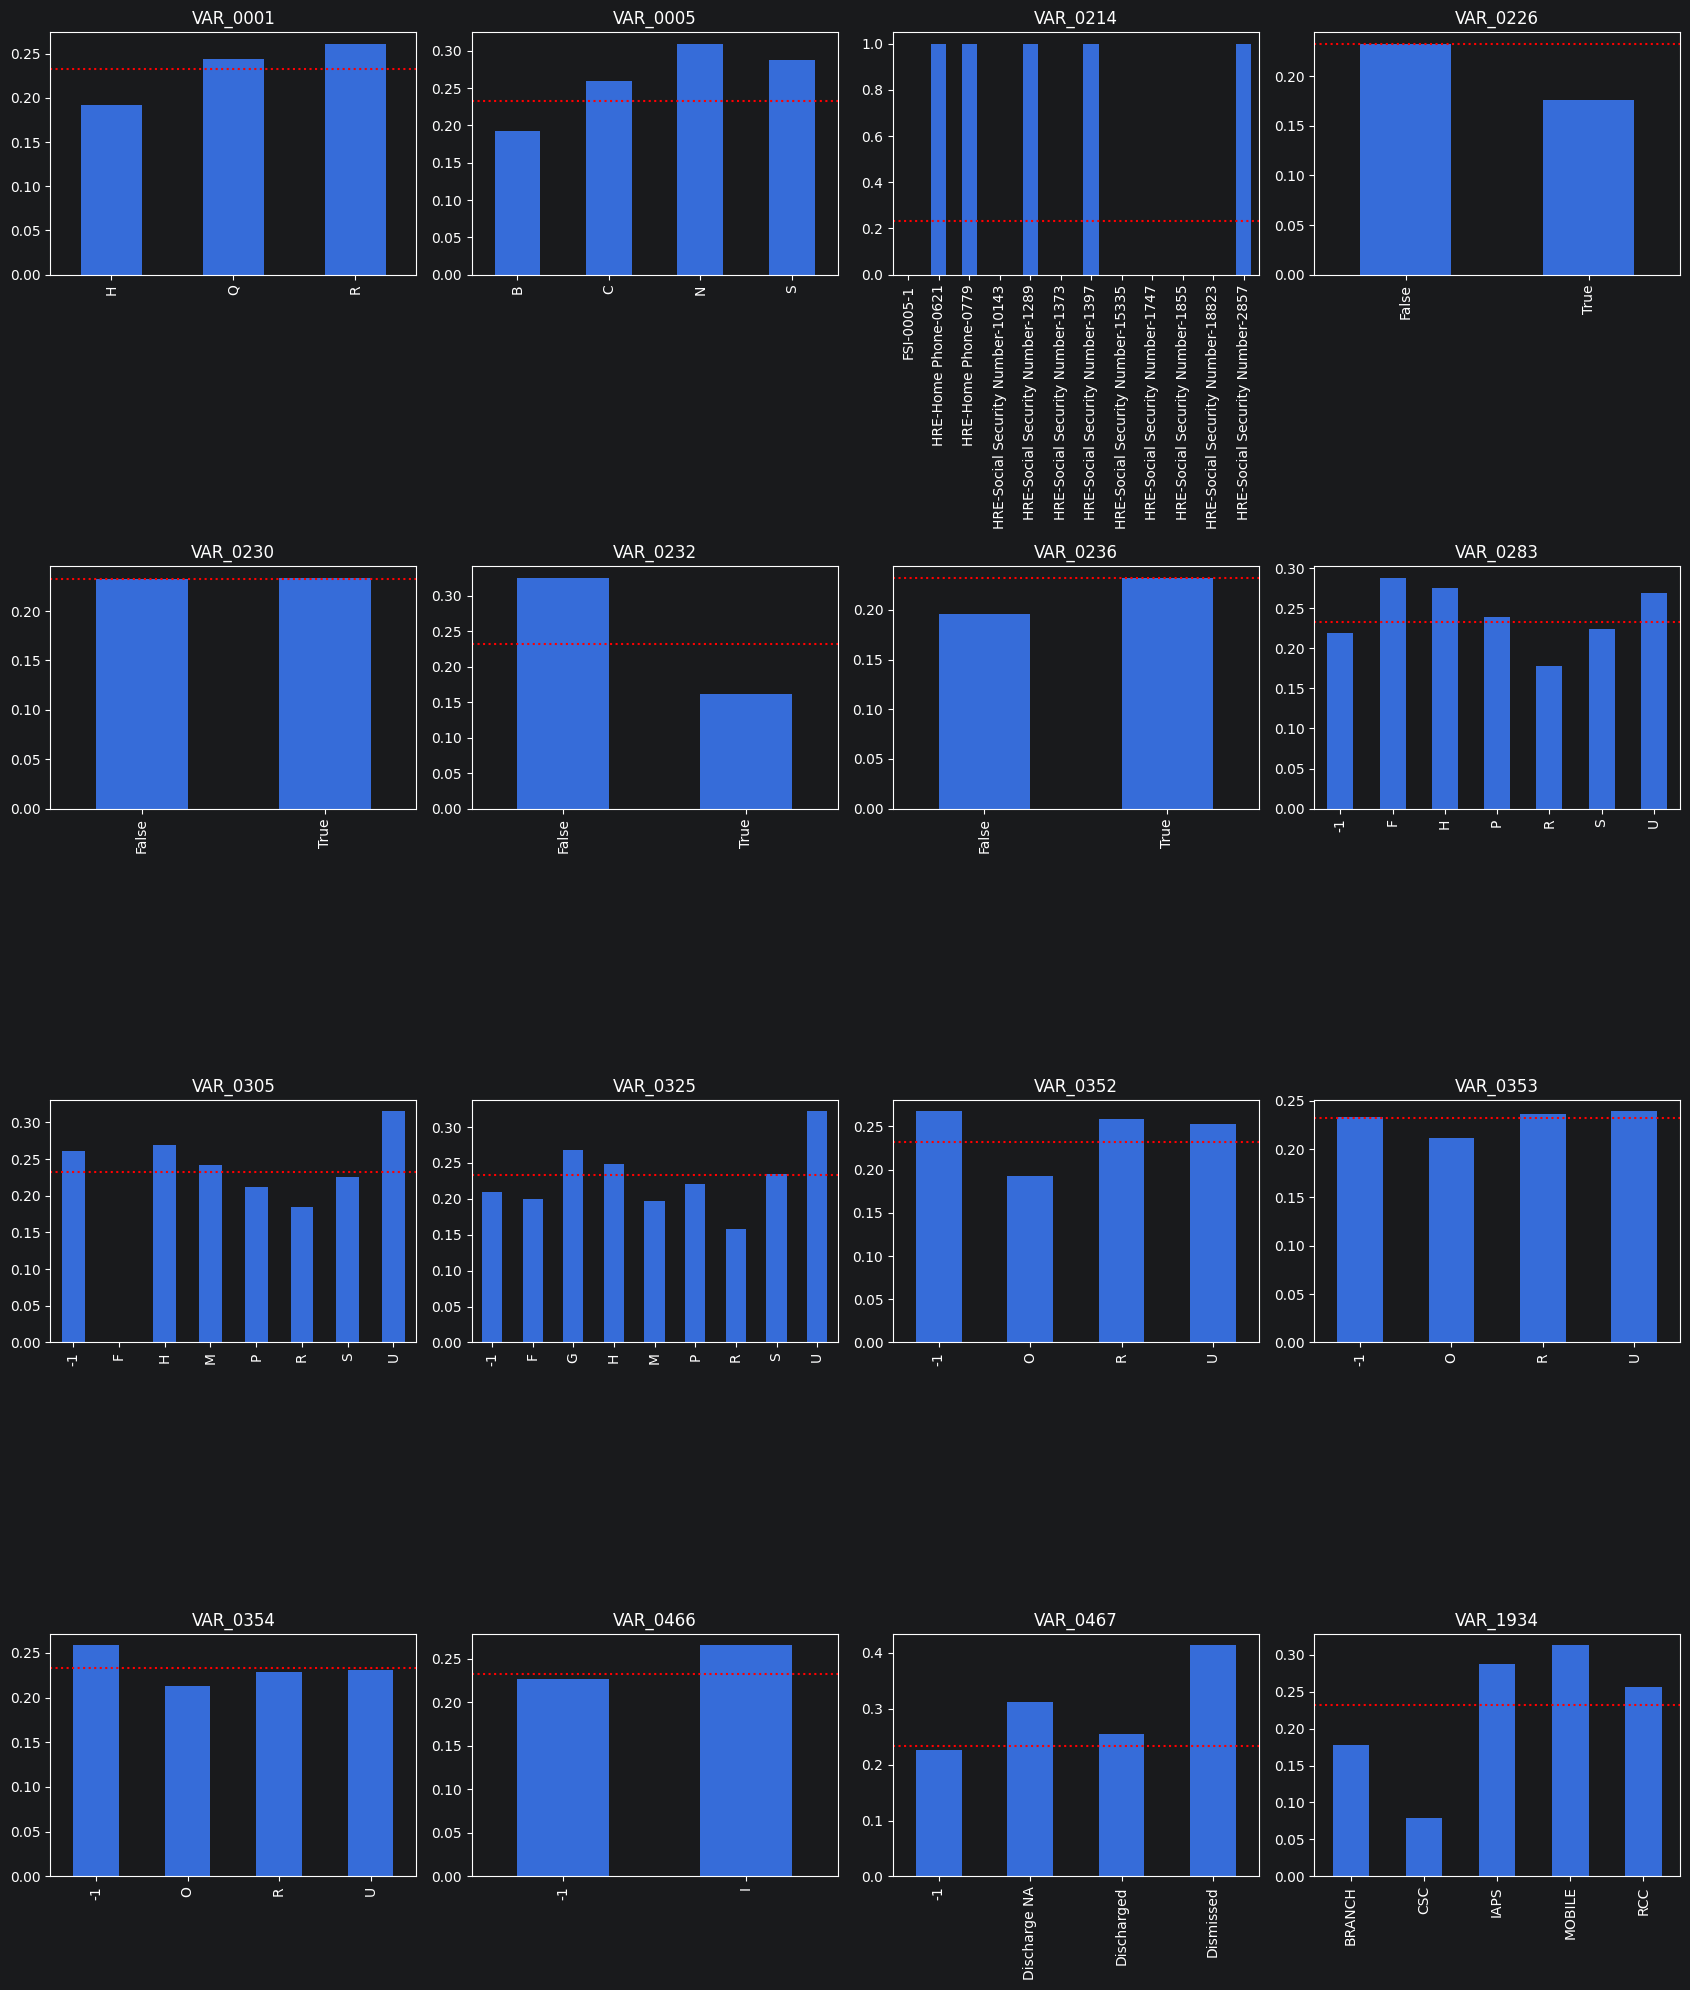

Some categorical text features show promising predictive power for the target variable.
However, our model selection gives us enough flexibility that we won't need to filter for these specific features.


In [12]:
# Text features with few enough categories to fit on a bar chart, nothing to do with the target yet. 
low_card_text = n_unique[(kind == 'text') & (n_unique >= 2) & (n_unique <= 20)].index
n_rows = (len(low_card_text) + 3) // 4

# Four plots across and as many rows as needed to fit them.
fig, axes = plt.subplots(n_rows, 4, figsize=(17, 5 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, low_card_text):
    df.groupby(col)['target'].mean().plot.bar(ax=ax)
    # red line is overall response rate, so bars far from it are the promising ones.
    ax.axhline(df['target'].mean(), color='red', linestyle='dotted')
    ax.set_title(col)
    ax.set_xlabel('')

# Remove leftover empty plots .
for ax in axes[len(low_card_text):]:
    ax.remove()

plt.tight_layout()
plt.show()

print('Some categorical text features show promising predictive power for the target variable.')
print('However, our model selection gives us enough flexibility that we won\'t need to filter for these specific features.')

## Data Cleaning and Preperation for Machine Learning

* Perform any data cleaning. Be clear what are you doing, for what feature.
* Determinine if rescaling is important for your Machine Learning model.
    * If so select strategy for each feature.
    * Apply rescaling.
* Visualize the features before and after cleaning and rescaling.
* One-hot encode your categorical features.

In [13]:
# useless columns containing no real information.
constant_features = n_unique[n_unique <= 1].index
df_clean = df.drop(columns=constant_features)
print(f'Dropped {len(constant_features)} constant columns.')

# Duplicate columns. This takes FOREVER to run.
check_cols = df_clean.columns.drop(['ID', 'target'])
duplicate_features = check_cols[df_clean[check_cols].T.duplicated()]
df_clean = df_clean.drop(columns=duplicate_features)

print(f'Dropped {len(duplicate_features)} duplicate features.')
print(f'Columns before cleaning: {df.shape[1]}')
print(f'Columns after cleaning: {df_clean.shape[1]}')

min_support = 100
support_count = df_clean.drop(columns=['ID', 'target']).notna().sum()
low_support_features = support_count[support_count < min_support].index
df_clean = df_clean.drop(columns=low_support_features)

print(f'Dropped {len(low_support_features)} features with fewer than {min_support} non-null rows.')
print('These hold too little data to be meaningful.')

print('Date clean-up work, just making some reasonable assumptions.\n')
date_format = '%d%b%y:%H:%M:%S'
reference_date = pd.Timestamp('2010-01-01')

text_features = df_clean.select_dtypes(exclude=[np.number]).columns

date_features = []
category_features = []

for col in text_features:
    parsed_dates = pd.to_datetime(df_clean[col], format=date_format, errors='coerce')

    filled_count = df_clean[col].notna().sum()
    parsed_count = parsed_dates.notna().sum()

    if filled_count > 0 and parsed_count > filled_count / 2:
        df_clean[col] = (parsed_dates - reference_date).dt.days
        date_features.append(col)
    else:
        df_clean[col] = df_clean[col].astype('category').cat.codes.replace(-1, np.nan)
        category_features.append(col)

print('If a column can parse as a date, it will be categorized as one.')
print('Otherwise, it will be a categorical column. This is only in regards to text columns.')

Dropped 54 constant columns.
Dropped 12 duplicate features.
Columns before cleaning: 1934
Columns after cleaning: 1868
Dropped 1 features with fewer than 100 non-null rows.
These hold too little data to be meaningful.
Date clean-up work, just making some reasonable assumptions.

If a column can parse as a date, it will be categorized as one.
Otherwise, it will be a categorical column. This is only in regards to text columns.


In [14]:
print('For our choice of ML model, rescaling is not needed. HistGradientBoostingClassifier works well')
print('with unscaled data. We avoided one-hot encoding because this would massively expand the width')
print('of our already impractically wide dataframe.\n')

For our choice of ML model, rescaling is not needed. HistGradientBoostingClassifier works well
with unscaled data. We avoided one-hot encoding because this would massively expand the width
of our already impractically wide dataframe.



Here we will take a closer look at the "assumed placeholder" values from earlier.
it's possible that these are actually ordinary or max values of the features.

Placeholder handling:
Each column is checked against the placeholder list one value at a time.
We will assume huge values are always a placeholder and smaller ones are a placeholder if they barely appear.
Replaced 62486554 placeholder values with NaN.


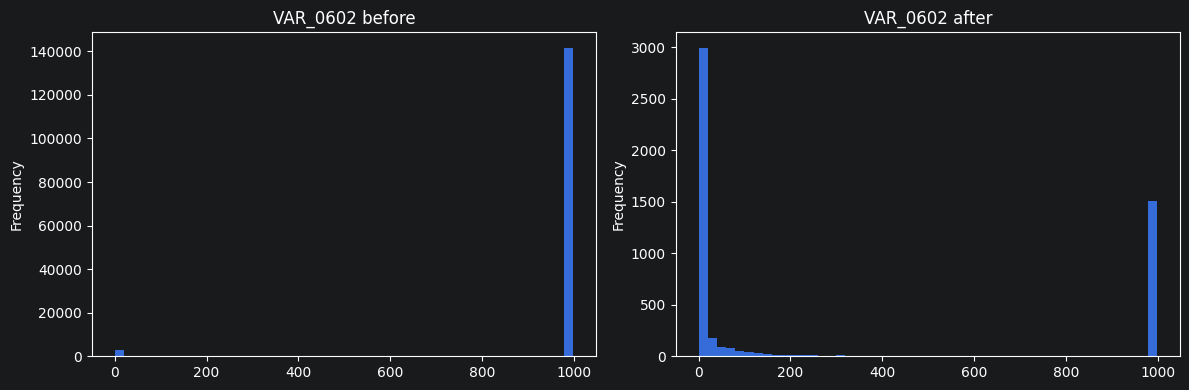

VAR_0602 shows what the cleaning actually does.
Non-null rows before: 145231
Non-null rows after: 5113
The placeholder was hiding the real distribution, which only spans 0 to 990.


In [15]:
print('Here we will take a closer look at the "assumed placeholder" values from earlier.')
print("it's possible that these are actually ordinary or max values of the features.\n")

# Nothing here is really measured in the hundreds of millions, so these are fake whereverthey show up.
always_placeholders = [999999996, 999999997, 999999998, 999999999]

# Smaller placeholders like 98 or 999 could potentially be real values, so they'll only count as a placeholder when they takes up a tiny share of the column.
spike_threshold = 0.01

example_col = 'VAR_0602'
before_values = df_clean[example_col].copy()

numeric_col = df_clean.select_dtypes(include=[np.number]).columns.drop(['ID', 'target'])

replaced_cells = 0
replaced_columns = []

for col in numeric_col:
    values = df_clean[col]
    replaced_here = 0

    for placeholder in assumed_placeholders:
        count = (values == placeholder).sum()
        share = count / len(values)

        if placeholder in always_placeholders:
            blank_it = count > 0
        else:
            blank_it = share > spike_threshold

        if blank_it:
            values = values.replace(placeholder, np.nan)
            replaced_here += count

    if replaced_here > 0:
        df_clean[col] = values
        replaced_cells += replaced_here
        replaced_columns.append(col)

print('Placeholder handling:')
print('Each column is checked against the placeholder list one value at a time.')
print('We will assume huge values are always a placeholder and smaller ones are a placeholder if they barely appear.')
print(f'Replaced {replaced_cells} placeholder values with NaN.')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

before_values.plot.hist(bins=50, ax=axes[0])
axes[0].set_title(f'{example_col} before')

df_clean[example_col].plot.hist(bins=50, ax=axes[1])
axes[1].set_title(f'{example_col} after')

plt.tight_layout()
plt.show()

## Machine Learning


### Problem Formulation

* Remove unneed columns, for example:
    * duplicated
    * categorical features that were turned into one-hot.
    * features that identify specific rows, like ID number.
    * make sure your target is properly encoded also.
* Split training sample into train, validation, and test sub-samples.

### Train ML Algorithm

* You only need one algorithm to work. You can do more if you like.
* For now, focus on making it work, rather than best result.
* Try to get a non-trivial result.

### Evaluate Performance on Validation Sample

* Compute the usual metric for your ML task.
* Compute the score for the kaggle challenge.

### Apply ML to the challenge test set

* Once trained, apply the ML algorithm the the test dataset and generate the submission file.


In [25]:
# We removed un-needed columns already in the previous section, discrimation based mostly on
# the fact that some columns contained literally no data or were duplicated.

X = df_clean.drop(columns=['ID', 'target'])
y = df_clean['target']

# We used a more "manual" version of this in class, but I prefer this method.
X_train, X_rest, y_train, y_rest = train_test_split(X, y, test_size=0.4, random_state=0, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(X_rest, y_rest, test_size=0.5, random_state=0, stratify=y_rest)

print('Splitting into train, validation, and test (60/20/20):')
print(f'train: {len(X_train)} rows.')
print(f'validation: {len(X_val)} rows.')
print(f'test: {len(X_test)} rows.')

Splitting into train, validation, and test (60/20/20):
train: 87138 rows.
validation: 29046 rows.
test: 29047 rows.


In [23]:
model = HistGradientBoostingClassifier(max_iter=500, learning_rate=0.05, early_stopping=True, validation_fraction=0.1, random_state=0)
model.fit(X_train, y_train)

print('HistGradientBoostingClassifier was chosen for four reasons:')
print('I (Christian) happened to randomly choose it for lab 8, so I\'m a little familiar with it.')
print('It handles NaN without issue, so missing data doesn\'t need imputing, no rescaling, since ')
print('its tree-based, and apparently its well-suited for very wide data.')
print(f'Training stopped after {model.n_iter_} of {model.max_iter} iterations.')

HistGradientBoostingClassifier was chosen for four reasons:
I (Christian) happened to randomly choose it for lab 8, so I'm a little familiar with it
It handles NaN without issue, so missing data doesn't need imputing, no rescaling, since 
its tree-based, and apparently its well-suited for very wide data.
Training stopped after 225 of 500 iterations.


Evaluation on the validation set:
Kaggle scored this problem on AUC, which is why we selected it here.

Validation AUC: 0.7820
Test AUC: 0.7789
Very close AUC, I don' think it's overfitting.


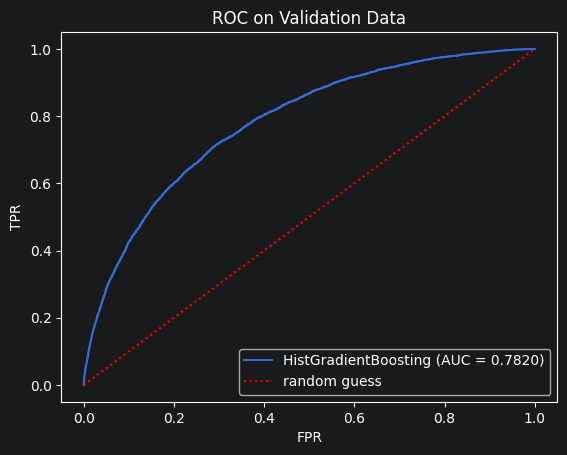

In [22]:
val_scores = model.predict_proba(X_val)[:, 1]
val_predictions = model.predict(X_val)
val_auc = roc_auc_score(y_val, val_scores)

print('Evaluation on the validation set:')
print('Kaggle scored this problem on AUC, which is why we selected it here.\n')
test_scores = model.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, test_scores)

print(f'Validation AUC: {val_auc:.4f}')
print(f'Test AUC: {test_auc:.4f}')
print('Very close AUC, I don\' think it\'s overfitting.')

fpr, tpr, thresholds = roc_curve(y_val, val_scores)

plt.plot(fpr, tpr, label=f'HistGradientBoosting (AUC = {val_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='dotted', color='red', label='random guess')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC on Validation Data')
plt.legend()
plt.show()

In [19]:
# TODO Kaggle submission.